In [1]:
import pandas as pd
import pickle
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score

# import easyMPRA as em
from _helper_functions import *

import os
import warnings
warnings.filterwarnings('ignore')

In [40]:

df=pd.read_pickle('bulkMPRA_reproducibility.pkl')

In [26]:
df

,pool-sumR/sumD-1-filtNa-Dnotnull,pool-sumR/sumD-2-filtNa-Dnotnull,pool-sumR/sumD-3-filtNa-Dnotnull,pool-sumR/sumD-1-filtNa-Dnotnull-log2,pool-sumR/sumD-1-filtNa-Dnotnull-minActFilt0.15,pool-sumR/sumD-1-filtNa-Dnotnull-minActFilt0.15-log2,pool-sumR/sumD-2-filtNa-Dnotnull-log2,pool-sumR/sumD-2-filtNa-Dnotnull-minActFilt0.15,pool-sumR/sumD-2-filtNa-Dnotnull-minActFilt0.15-log2,pool-sumR/sumD-3-filtNa-Dnotnull-log2,pool-sumR/sumD-3-filtNa-Dnotnull-minActFilt0.15,pool-sumR/sumD-3-filtNa-Dnotnull-minActFilt0.15-log2,merge,WT Activity,is_inert,is_active,rep,act,label,xdummy
enhancer-seq_y,,,,,,,,,,,,,,,,,,,,
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGGAAGTTTTCGAAGAGATAACA,1.731750,1.483470,1.345716,0.792230,1.731750,0.792230,0.568976,1.483470,0.568976,0.428374,1.345716,0.428374,1.789580,0.83,False,False,NaN,NaN,NaN,NaN
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGGAAGTTTTCGAAGTTATCTCA,0.863720,0.000000,0.302816,-0.211364,0.863720,-0.211364,NaN,NaN,NaN,-1.723487,0.302816,-1.723487,-1.934850,-0.93,True,False,NaN,NaN,NaN,NaN
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACTTCCGTTTTCGAAGAGATAACA,1.418789,3.948297,1.024667,0.504660,1.418789,0.504660,1.981231,3.948297,1.981231,0.035155,1.024667,0.035155,2.521045,1.19,False,True,NaN,NaN,NaN,NaN
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACTTCCGTTTTCGAAGTTATCTCA,0.319073,0.000000,1.241021,-1.648041,0.319073,-1.648041,NaN,NaN,NaN,0.311528,1.241021,0.311528,-1.336513,-0.55,True,False,NaN,NaN,NaN,NaN
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCGAGATAACTTTCGAAACGGAAGTA,0.367226,1.327721,0.000000,-1.445261,0.367226,-1.445261,0.408952,1.327721,0.408952,NaN,NaN,NaN,-1.036309,-0.48,True,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAAGTTATCTCTGCTCCCTATCTTTAATTTCCTTCATCTGAAGCTCACGGAAGTAGATATTA,0.410566,0.453815,0.841375,-1.284316,0.410566,-1.284316,-1.139824,0.453815,-1.139824,-0.249180,0.841375,-0.249180,-2.673319,-0.96,True,False,NaN,NaN,NaN,NaN
TTTCGAAGTTATCTCTGCTCCCTATCTTTAATTTCCTTCATCTGAAGCTCACTTCCGTAATATCTA,2.051640,0.996721,1.088128,1.036777,2.051640,1.036777,-0.004738,0.996721,-0.004738,0.121848,1.088128,0.121848,1.153887,0.73,False,False,NaN,NaN,NaN,NaN
TTTCGAAGTTATCTCTGCTCCCTATCTTTAATTTCCTTCATCTGAAGCTCACTTCCGTAGATATTA,1.230897,0.419164,0.735565,0.299710,1.230897,0.299710,-1.254412,0.419164,-1.254412,-0.443076,0.735565,-0.443076,-1.397778,-0.06,True,False,NaN,NaN,NaN,NaN


(-3.0, 8.0)

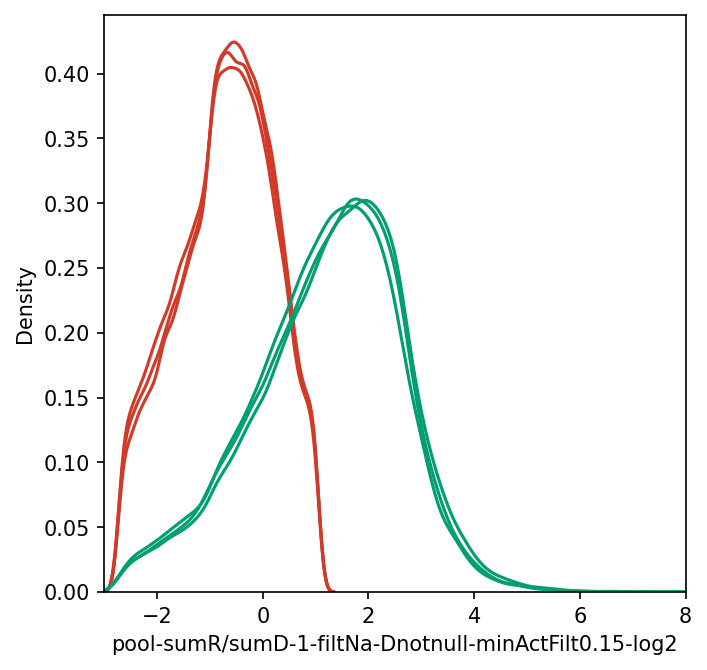

In [27]:
fig, ax = quickfig()
data = [
    (df.loc[df['is_inert'], 'pool-sumR/sumD-1-filtNa-Dnotnull-minActFilt0.15-log2'], cb['orangenature']),
    (df.loc[df['is_inert'], 'pool-sumR/sumD-2-filtNa-Dnotnull-minActFilt0.15-log2'], cb['orangenature']),
    (df.loc[df['is_inert'], 'pool-sumR/sumD-3-filtNa-Dnotnull-minActFilt0.15-log2'], cb['orangenature']),
    (df.loc[df['is_active'], 'pool-sumR/sumD-1-filtNa-Dnotnull-minActFilt0.15-log2'], cb['green']),
    (df.loc[df['is_active'], 'pool-sumR/sumD-2-filtNa-Dnotnull-minActFilt0.15-log2'], cb['green']),
    (df.loc[df['is_active'], 'pool-sumR/sumD-3-filtNa-Dnotnull-minActFilt0.15-log2'], cb['green']),
]
for di, ci in data:
    sns.kdeplot(di, color=ci)
ax.set_xlim(-3, 8)

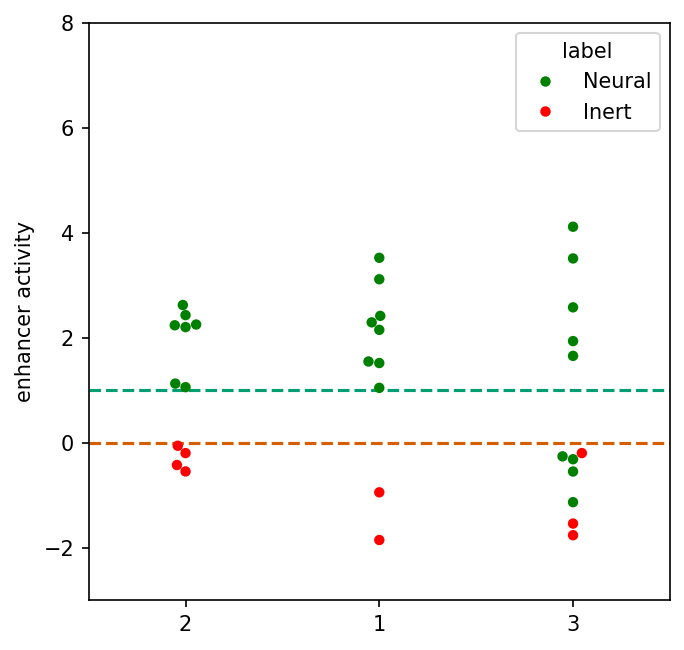

In [28]:
fig,ax=quickfig()

sns.swarmplot(df[df['xdummy']==0],x='rep',y='act',hue='label',palette={'Inert':'red','Neural':'green'})
ax.set_ylim(-3,8)

ax.axhline(0,color=cb['red'],ls='--')
ax.axhline(1,color=cb['green'],ls='--')

ax.set_xlabel('')
ax.set_ylabel('enhancer activity')
plt.show()

In [29]:
import matplotlib.colors
from scipy.stats import rankdata
from matplotlib.patches import Patch


def plot_replicate_reproducibility(
    df,
    rep_cols,
    mean_col,
    lo=0,
    hi=1,
    mean_lo=0,
    mean_hi=3,
    n_strip=800,
    save_path=None,
    strip_by_rank=False,
    n_top=None,
    n_bot=None,
):
    assert len(rep_cols) == 3, "rep_cols must be exactly 3 column names"

    cols = list(dict.fromkeys(rep_cols + [mean_col]))
    complete = df[cols].dropna().copy().reset_index(drop=True)
    n = len(complete)

    # Kendall's W
    mat = complete[rep_cols].values
    ranks = np.apply_along_axis(rankdata, 0, mat)
    k = ranks.shape[1]
    S = np.sum((ranks.sum(axis=1) - ranks.sum() / n) ** 2)
    W = 12 * S / (k**2 * (n**3 - n))

    if W < 0.20:
        interp = "slight"
    elif W < 0.40:
        interp = "fair"
    elif W < 0.60:
        interp = "moderate"
    elif W < 0.80:
        interp = "substantial"
    else:
        interp = "almost perfect"

    def classify(v, l=lo, h=hi):
        v = np.asarray(v, float)
        out = np.full(len(v), "unclass", dtype=object)
        out[v > h] = "active"
        out[v < l] = "inert"
        return out

    def to_num(arr):
        return np.where(arr == "active", 2, np.where(arr == "inert", 0, 1))

    # Panel A data
    complete_sorted = complete.sort_values(mean_col).reset_index(drop=True)
    step = max(1, len(complete_sorted) // n_strip)
    sample = complete_sorted.iloc[::step].iloc[:n_strip]

    if strip_by_rank:
        if n_bot is not None and n_top is not None:
            split_idx = int(len(sample) * n_bot / (n_bot + n_top))
        else:
            split_idx = len(sample) // 2

        rank_colors = np.where(np.arange(len(sample)) >= split_idx, 2, 0)
        img = np.stack([rank_colors] * (len(rep_cols) + 1))
    else:
        img = np.stack(
            [to_num(classify(sample[c].values)) for c in rep_cols] +
            [to_num(classify(sample[mean_col].values, l=mean_lo, h=mean_hi))]
        )

    cmap3 = matplotlib.colors.ListedColormap(["tab:red", "tab:orange", "tab:green"])
    thresh_lo = (sample[mean_col] < mean_lo).sum()
    thresh_hi = (sample[mean_col] < mean_hi).sum()

    print(f"\n{'='*60}")
    print(f"Kendall's W        = {W:.4f}  ({interp} concordance)")
    print(f"n complete cases   = {n:,}")
    print(f"rep thresholds     : inert < {lo},      active > {hi}")
    print(f"merge thresholds   : inert < {mean_lo}, active > {mean_hi}")
    print(f"strip_by_rank      = {strip_by_rank}  (n_bot={n_bot}, n_top={n_top})")
    print("Citation: Landis JR, Koch GG. Biometrics. 1977;33(1):159-174. PMID:843571")
    print(f"{'='*60}\n")

    # Wider than the old single-panel size because y labels are long
    # and the legend is placed outside the plotting area.
    fig, ax_a = plt.subplots(1, 1, figsize=(10, 5))

    fig.suptitle(
        f"{len(rep_cols)} biological replicates  |  "
        f"Kendall's W = {W:.3f}  |  {n:,} complete cases\n"
        f"Landis & Koch (1977): W 0.41-0.60 = moderate concordance",
        fontsize=10
    )

    row_labels = [mean_col] + list(reversed(rep_cols))

    ax_a.imshow(
        img,
        aspect="auto",
        cmap=cmap3,
        vmin=0,
        vmax=2,
        interpolation="nearest",
        extent=[0, n_strip, 0, len(row_labels)]
    )

    ax_a.set_yticks([i + 0.5 for i in range(len(row_labels))])
    ax_a.set_yticklabels(row_labels)

    ax_a.set_xticks([0, n_strip // 4, n_strip // 2, 3 * n_strip // 4, n_strip])
    ax_a.set_xticklabels(["low", "", "", "", "high"])

    ax_a.set_xlabel(f"Elements sorted by {mean_col}  (low -> high)")
    ax_a.set_title(
        f"A  |  Rank concordance across {len(rep_cols)} replicates\n"
        f"Kendall's W = {W:.3f}"
    )

    if strip_by_rank:
        ax_a.axvline(split_idx, color="black", lw=1.5, ls="--")
        pct_bot = 100 * split_idx / len(sample)
        legend_els = [
            Patch(fc="tab:red", label=f"bottom {pct_bot:.0f}% by merge rank  (n={n_bot})"),
            Patch(fc="tab:green", label=f"top {100-pct_bot:.0f}% by merge rank  (n={n_top})"),
        ]
    else:
        ax_a.axvline(thresh_lo, color="black", lw=1.5, ls="--")
        ax_a.axvline(thresh_hi, color="black", lw=1.5, ls="--")
        legend_els = [
            Patch(fc="tab:red", label=f"inert (rep<{lo}, merge<{mean_lo})"),
            Patch(fc="tab:orange", label="unclass"),
            Patch(fc="tab:green", label=f"active (rep>{hi}, merge>{mean_hi})"),
        ]

    # Legend outside, so it does not cover the heatmap.
    ax_a.legend(
        handles=legend_els,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=False
    )

    # More left margin for long y-axis labels;
    # more right margin for outside legend.
    fig.subplots_adjust(
        left=0.35,
        right=0.78,
        top=0.82,
        bottom=0.18
    )

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    plt.show()
    return W

In [30]:
minActCutoff=0.15


Kendall's W        = 0.4659  (moderate concordance)
n complete cases   = 164,634
rep thresholds     : inert < 0,      active > 1
merge thresholds   : inert < 0, active > 1
strip_by_rank      = False  (n_bot=None, n_top=None)
Citation: Landis JR, Koch GG. Biometrics. 1977;33(1):159-174. PMID:843571



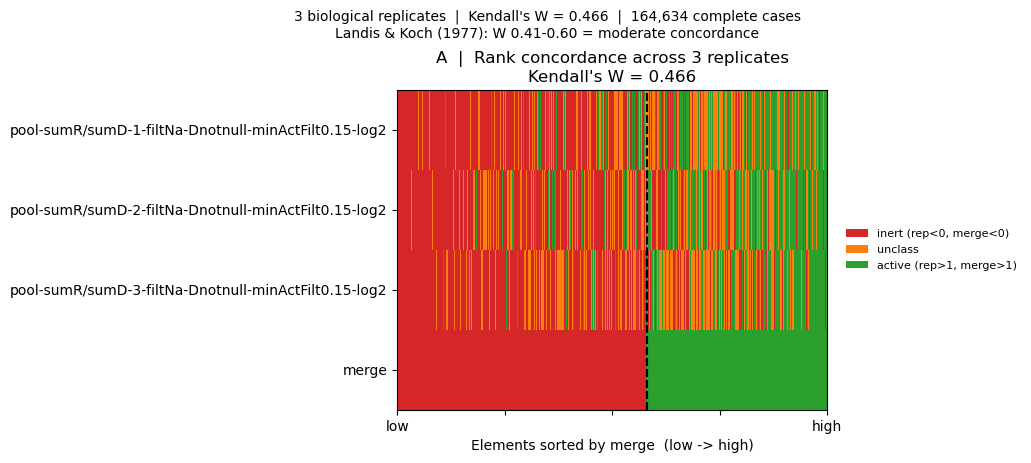

In [34]:
plotdf=df.loc[(df['merge']>1) | (df['merge']<0), :].copy(deep=True)
W = plot_replicate_reproducibility(
    plotdf,
    rep_cols=[f'pool-sumR/sumD-[[rep]]-filtNa-Dnotnull-minActFilt{minActCutoff}-log2'.replace('[[rep]]',str(i)) for i in [1,2,3]],
    mean_col='merge',mean_lo=0, mean_hi=1,
)


Kendall's W        = 0.7507  (substantial concordance)
n complete cases   = 20,000
rep thresholds     : inert < 0,      active > 1
merge thresholds   : inert < 0, active > 1
strip_by_rank      = False  (n_bot=None, n_top=None)
Citation: Landis JR, Koch GG. Biometrics. 1977;33(1):159-174. PMID:843571



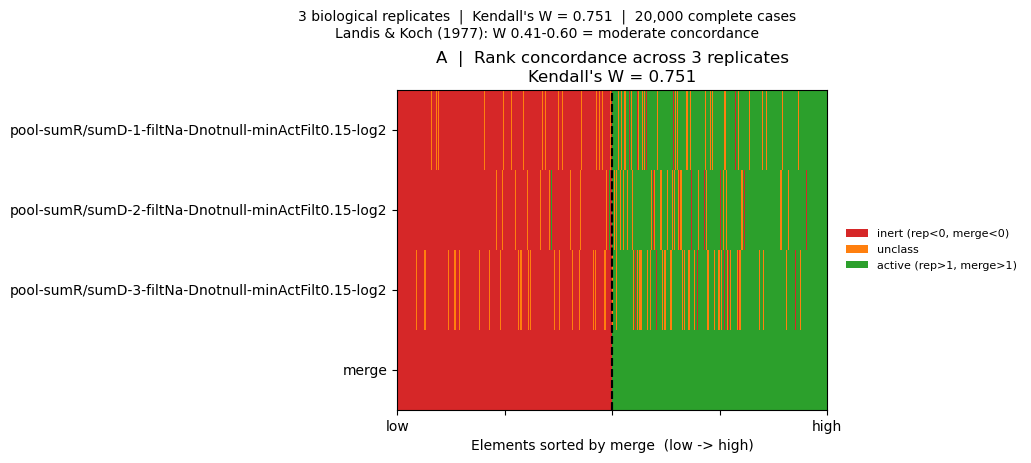

In [41]:
pdf=df.drop(columns = ['is_inert', 'is_active','rep', 'act', 'label', 'xdummy']).sort_values('merge',ascending=False).reset_index(drop=True).dropna(how='any')

lo=10000
hi=10000
l=list(range(hi))+list(range(-lo,0))

W = plot_replicate_reproducibility(
    pdf.iloc[l,:],
    rep_cols=[f'pool-sumR/sumD-[[rep]]-filtNa-Dnotnull-minActFilt{minActCutoff}-log2'.replace('[[rep]]',str(i)) for i in [1,2,3]],
    mean_col='merge',mean_lo=0, mean_hi=1,
)